In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy

In [22]:
def call_dataset(path, subj, modality, session):
    path = path + subj + '/'
    if modality=='EMG':
        bluetooth_id = 'E8DD80E550BB'
    elif modality=='ENG':
        bluetooth_id = 'E9AD0E7DCC2B'
    else:
        print("modality must be EMG or ENG")

    dataset = []
    data_per_class_files = os.listdir(path+f'{modality}_{session}/{bluetooth_id}/raw/')
    for cls in data_per_class_files:
        input_path = path+f'{modality}_{session}/{bluetooth_id}/raw/{cls}/'
        files = os.listdir(input_path)
        mat = scipy.io.loadmat(input_path+files[0])
        #dict_keys(['__header__', '__version__', '__globals__', 'Data_ADC', 'Data_Cls', 'Data_Fea', 'Dev_Channels', 'Dev_Info', 'Dev_NCh'])
        dataset.append(mat)

    return dataset

In [14]:
import os
import scipy.io
import numpy as np
from scipy.signal import iirnotch, filtfilt

def notch_filter_60Hz(data, fs=round(10e6 / 2048)):
    """
    Apply 60 Hz + harmonic (120 Hz) notch filters.
    Adjust fs to your actual sampling rate.
    """
    filtered = data

    freqs_to_remove = [60, 120, 180, 240, 300, 360, 420, 480, 540, 600, 660, 720, 780, 840, 900, 960]  # extend to [60,120,180] if needed
    Q = 30

    for f0 in freqs_to_remove:
        w0 = f0 / (fs / 2)   # normalized freq
        b, a = iirnotch(w0, Q)
        filtered = filtfilt(b, a, filtered, axis=0)

    return filtered


def call_dataset(path, subj, modality, session, fs=round(10e6 / 2048)):
    path = path + subj + '/'

    if modality == 'EMG':
        bluetooth_id = 'E8DD80E550BB'
    elif modality == 'ENG':
        bluetooth_id = 'E9AD0E7DCC2B'
    else:
        raise ValueError("modality must be EMG or ENG")

    dataset = []
    data_per_class_files = os.listdir(path + f'{modality}_{session}/{bluetooth_id}/raw/')

    for cls in data_per_class_files:
        input_path = path + f'{modality}_{session}/{bluetooth_id}/raw/{cls}/'
        files = os.listdir(input_path)
        mat = scipy.io.loadmat(input_path + files[0])

        data = mat["Data_ADC"]   # shape: (channels, samples)

        # ---------------------------------------------
        # 🔥 Apply PLN (60 Hz) removal ONLY for EMG
        # ---------------------------------------------
        if modality == 'EMG':
            # Data_ADC is channels × samples → filter along samples axis
            data = notch_filter_60Hz(data.T, fs=fs).T
            mat["Data_ADC"] = data

        dataset.append(mat)

    return dataset

In [15]:
path = 'C:/Users/hml76/PycharmProjects/MindForce/data/EMG_ENG/'

subject_names = os.listdir(path)

subjects_EMG_v1, subjects_ENG_v1 = [], []

for i in subject_names:
    EMG_all = call_dataset(path, subj=i, modality='EMG', session='v1')
    subjects_EMG_v1.append(EMG_all)
    ENG_all = call_dataset(path, subj=i, modality='ENG', session='v1')
    subjects_ENG_v1.append(ENG_all)

subjects_EMG_v2, subjects_ENG_v2 = [], []

for i in subject_names:
    EMG_all = call_dataset(path, subj=i, modality='EMG', session='v2')
    subjects_EMG_v2.append(EMG_all)
    ENG_all = call_dataset(path, subj=i, modality='ENG', session='v2')
    subjects_ENG_v2.append(ENG_all)

subjects_EMG = subjects_EMG_v1 + subjects_EMG_v2
subjects_ENG = subjects_ENG_v1 + subjects_ENG_v2

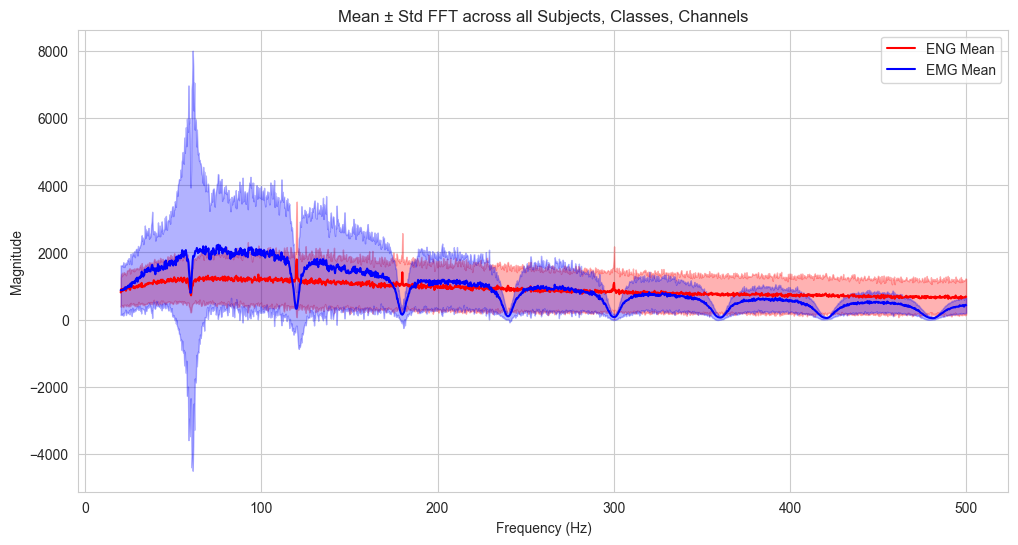

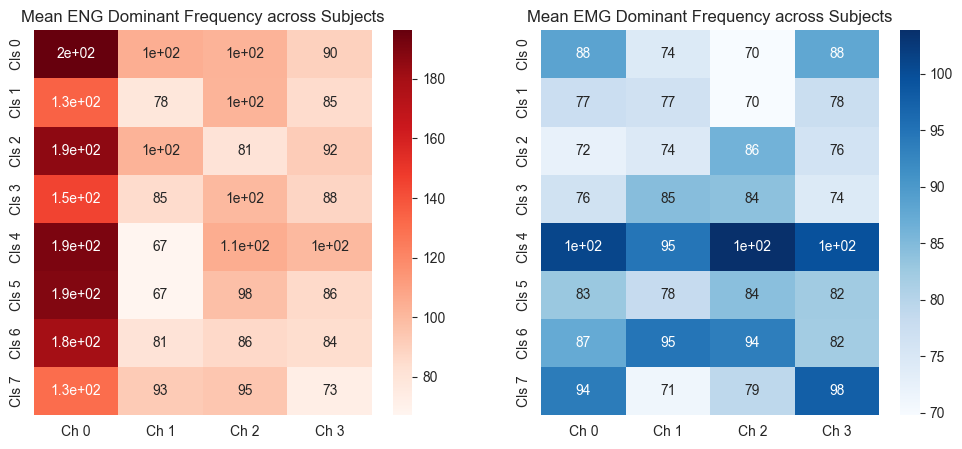

In [16]:
fs = round(10e6 / 2048)
num_subjects = 9
num_classes = 8
num_channels = min(len(EMG_all[0]['Data_ADC']), len(EMG_all[0]['Data_ADC']))

freq_min, freq_max = 20, 500
fft_len = 2**14  # zero-padding

# Dominant frequency matrix for all subjects
eng_dom_band_all = np.zeros((num_subjects, num_classes, num_channels))
emg_dom_band_all = np.zeros((num_subjects, num_classes, num_channels))

# Mean FFT across all subjects, classes, channels
all_freqs = None
eng_all_fft = []
emg_all_fft = []

for s_idx in range(num_subjects):
    EMG_all = subjects_EMG[s_idx]
    ENG_all = subjects_ENG[s_idx]

    for cls in range(num_classes):
        for ch in range(num_channels):
            # DC 제거
            eng_signal = ENG_all[cls]['Data_ADC'][ch] - np.mean(ENG_all[cls]['Data_ADC'][ch])
            emg_signal = EMG_all[cls]['Data_ADC'][ch] - np.mean(EMG_all[cls]['Data_ADC'][ch])

            # FFT
            eng_fft = np.fft.fft(eng_signal, n=fft_len)
            emg_fft = np.fft.fft(emg_signal, n=fft_len)
            freqs = np.fft.fftfreq(len(eng_fft), d=1/fs)

            # 주파수 범위 필터
            pos_mask = (freqs > 0) & (freqs >= freq_min) & (freqs <= freq_max)
            freqs = freqs[pos_mask]
            eng_fft_mag = np.abs(eng_fft[pos_mask])
            emg_fft_mag = np.abs(emg_fft[pos_mask])

            # Dominant frequency 저장
            eng_dom_band_all[s_idx, cls, ch] = freqs[np.argmax(eng_fft_mag)]
            emg_dom_band_all[s_idx, cls, ch] = freqs[np.argmax(emg_fft_mag)]

            # 전체 FFT 저장
            eng_all_fft.append(eng_fft_mag)
            emg_all_fft.append(emg_fft_mag)

    # freqs는 동일하므로 한 번만 저장
    if all_freqs is None:
        all_freqs = freqs

eng_all_fft = np.array(eng_all_fft)
emg_all_fft = np.array(emg_all_fft)

# 평균 ± 표준편차 계산
eng_mean_fft = np.mean(eng_all_fft, axis=0)
eng_std_fft = np.std(eng_all_fft, axis=0)
emg_mean_fft = np.mean(emg_all_fft, axis=0)
emg_std_fft = np.std(emg_all_fft, axis=0)

# --- Visualization ---

# 1. Mean ± Std Spectrum
plt.figure(figsize=(12,6))
plt.plot(all_freqs, eng_mean_fft, color='red', label='ENG Mean')
plt.fill_between(all_freqs, eng_mean_fft-eng_std_fft, eng_mean_fft+eng_std_fft, color='red', alpha=0.3)
plt.plot(all_freqs, emg_mean_fft, color='blue', label='EMG Mean')
plt.fill_between(all_freqs, emg_mean_fft-emg_std_fft, emg_mean_fft+emg_std_fft, color='blue', alpha=0.3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Mean ± Std FFT across all Subjects, Classes, Channels')
plt.legend()
plt.show()

# 2. Dominant Frequency Heatmap (subjects x classes x channels)

'''for s_idx in range(num_subjects):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.heatmap(eng_dom_band_all[s_idx], annot=True, cmap='Reds', xticklabels=[f'Ch {i}' for i in range(num_channels)],
                yticklabels=[f'Cls {i}' for i in range(num_classes)])
    plt.title(f'Subject {s_idx+1} ENG Dominant Frequency (Hz)')

    plt.subplot(1,2,2)
    sns.heatmap(emg_dom_band_all[s_idx], annot=True, cmap='Blues', xticklabels=[f'Ch {i}' for i in range(num_channels)],
                yticklabels=[f'Cls {i}' for i in range(num_classes)])
    plt.title(f'Subject {s_idx+1} EMG Dominant Frequency (Hz)')
    plt.show()
'''
# 3. 전체 subjects 평균 dominant frequency per class-channel
eng_mean_dom = np.mean(eng_dom_band_all, axis=0)
emg_mean_dom = np.mean(emg_dom_band_all, axis=0)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(eng_mean_dom, annot=True, cmap='Reds', xticklabels=[f'Ch {i}' for i in range(num_channels)],
            yticklabels=[f'Cls {i}' for i in range(num_classes)])
plt.title('Mean ENG Dominant Frequency across Subjects')

plt.subplot(1,2,2)
sns.heatmap(emg_mean_dom, annot=True, cmap='Blues', xticklabels=[f'Ch {i}' for i in range(num_channels)],
            yticklabels=[f'Cls {i}' for i in range(num_classes)])
plt.title('Mean EMG Dominant Frequency across Subjects')
plt.show()


1️⃣ EMG (Electromyography) – Muscle Activity

- EMG records the electrical activity generated by muscle fibers.
- Frequency range of surface EMG: roughly 10–500 Hz.
- Dominant frequency (frequency with highest power): usually 50–150 Hz for most upper limb muscles during voluntary contraction.

Notes: For forearm and hand muscles innervated by ulnar/median nerves, dominant frequency often centers around 60–120 Hz. Muscle fatigue can shift the dominant frequency lower over time. Surface EMG has a high-pass filtering effect, so very low frequencies (<10 Hz) are often removed.

2️⃣ ENG (Electroneurography / Nerve Conduction) – Nerve Signals
- ENG measures compound nerve action potentials (CNAPs) along nerves.
- Frequency content of peripheral nerve signals is higher than EMG: 100–1000 Hz, sometimes even up to 3–4 kHz for fast-conducting fibers.
- Dominant frequency of ulnar/median nerve stimulation or recording:
- Typically 100–400 Hz for the main component of the recorded signal.
- Peaks are sharp and short (due to fast propagation), unlike EMG which is more broadband.

Notes: Nerve conduction velocity measurements use time-domain features more than frequency-domain, but frequency analysis shows high-frequency components due to synchronous activation of fibers. Filtering and electrode type influence the observed spectrum.

In [17]:
fs = round(10e6 / 2048)
fft_len = 2**14
num_classes = 8

# Store FFT magnitudes and dominant frequencies
eng_all_fft = []
emg_all_fft = []
eng_dom_freqs = []
emg_dom_freqs = []

for s_idx in range(num_subjects):
    EMG_all = subjects_EMG[s_idx]
    ENG_all = subjects_ENG[s_idx]

    for cls in range(num_classes):
        for ch in range(num_channels):
            # DC removal
            eng_signal = ENG_all[cls]['Data_ADC'][ch] - np.mean(ENG_all[cls]['Data_ADC'][ch])
            emg_signal = EMG_all[cls]['Data_ADC'][ch] - np.mean(EMG_all[cls]['Data_ADC'][ch])

            # FFT
            eng_fft = np.fft.fft(eng_signal, n=fft_len)
            emg_fft = np.fft.fft(emg_signal, n=fft_len)
            freqs = np.fft.fftfreq(len(eng_fft), d=1/fs)
            pos_mask = freqs > 0
            freqs = freqs[pos_mask]

            eng_fft_mag = np.abs(eng_fft[pos_mask])
            emg_fft_mag = np.abs(emg_fft[pos_mask])

            # Store FFT magnitudes
            eng_all_fft.append(eng_fft_mag)
            emg_all_fft.append(emg_fft_mag)

            # Store dominant frequencies
            eng_dom_freqs.append(freqs[np.argmax(eng_fft_mag)])
            emg_dom_freqs.append(freqs[np.argmax(emg_fft_mag)])

# Convert to arrays
eng_all_fft = np.array(eng_all_fft)
emg_all_fft = np.array(emg_all_fft)
eng_dom_freqs = np.array(eng_dom_freqs)
emg_dom_freqs = np.array(emg_dom_freqs)

# Mean, Std, Variance
eng_mean_fft = np.mean(eng_all_fft, axis=0)
eng_std_fft = np.std(eng_all_fft, axis=0)
eng_var_fft = np.var(eng_all_fft, axis=0)

emg_mean_fft = np.mean(emg_all_fft, axis=0)
emg_std_fft = np.std(emg_all_fft, axis=0)
emg_var_fft = np.var(emg_all_fft, axis=0)

# Variance of dominant frequency across all subjects/classes/channels
eng_dom_var = np.var(eng_dom_freqs)
emg_dom_var = np.var(emg_dom_freqs)
print(f'ENG dominant frequency variance: {eng_dom_var:.2f} Hz^2')
print(f'EMG dominant frequency variance: {emg_dom_var:.2f} Hz^2')

ENG dominant frequency variance: 6772.54 Hz^2
EMG dominant frequency variance: 986.00 Hz^2


In [12]:
np.mean(eng_dom_freqs), np.mean(emg_dom_freqs)

(np.float64(114.57156329684787), np.float64(83.6380483839247))

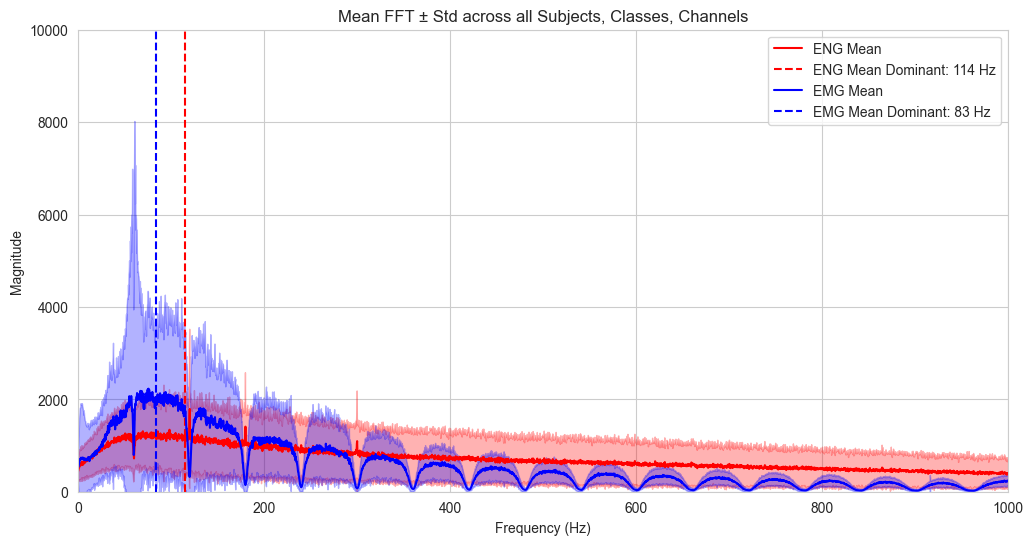

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

for signal_type, mean_fft, std_fft, dom_freq, color in zip(
    ['ENG','EMG'],
    [eng_mean_fft, emg_mean_fft],
    [eng_std_fft, emg_std_fft],
    [np.mean(eng_dom_freqs), np.mean(emg_dom_freqs)],
    ['red','blue']
):
    axes.plot(freqs, mean_fft, label=f'{signal_type} Mean', color=color)
    axes.fill_between(freqs, mean_fft-std_fft, mean_fft+std_fft, color=color, alpha=0.3)
    axes.axvline(dom_freq, color=color, linestyle='--', label=f'{signal_type} Mean Dominant: {int(dom_freq)} Hz')

axes.set_xlabel('Frequency (Hz)')
axes.set_ylabel('Magnitude')
axes.set_title('Mean FFT ± Std across all Subjects, Classes, Channels')
axes.legend()
axes.set_ylim(0,10000)
axes.set_xlim(0,1000)
plt.show()

# So-far

Data: Simultaneous dataset
1. ENG signal has higher frequency components in general across channels, gestures, and subjects (ENG: 114, 99)
    - This aligns with the domain knowledge